# Performance Analysis: Conway's Game of Life

This notebook benchmarks the Game of Life simulation across different grid sizes and processing strategies (single-process vs multiprocessing with varying worker counts). The goal is to determine the crossover point where multiprocessing becomes advantageous over single-process execution, and use this to set the `multiprocessing_threshold_cells` configuration default.


### Hardware Environment
The benchmarks below were executed on the following system:
- **CPU**: 13th Gen Intel Core i9-13950HX (32 threads @ 5.50 GHz)
- **GPU**: NVIDIA GeForce RTX 4060 Laptop GPU
- **RAM**: 32 GB
- **OS**: Ubuntu 24.04 x86_64


In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Add parent directory to path so we can import libs
sys.path.append(str(Path().resolve().parent))

from libs.config import BoundaryMode, SimulationConfig

In [2]:
grid_sizes = [20, 50, 100, 200, 500, 1000]
strategies = {
    "Single Process": {"type": "single"},
    "Multiprocess (2 Workers)": {"type": "multi", "workers": 2},
    "Multiprocess (4 Workers)": {"type": "multi", "workers": 4},
    "Multiprocess (8 Workers)": {"type": "multi", "workers": 8},
    "GPU (CuPy)": {"type": "gpu"},
}

num_generations = 20
results = []

for size in grid_sizes:
    shape = (size, size)
    print(f"Benchmarking {size}x{size} (Total Cells: {size * size})")

    # Generate random initial state
    initial_grid = np.random.choice([0, 1], size=shape, p=[0.8, 0.2]).astype(np.uint8)

    for name, strategy_config in strategies.items():
        grid_copy = initial_grid.copy()

        config = SimulationConfig(boundary_mode=BoundaryMode.TOROIDAL)

        from libs.config import ComputeBackend

        if strategy_config["type"] == "single":
            config.backend = ComputeBackend.CPU
            config.multiprocessing_threshold_cells = float("inf")
        elif strategy_config["type"] == "multi":
            config.backend = ComputeBackend.CPU
            config.multiprocessing_threshold_cells = 0
            config.n_workers = strategy_config["workers"]
        elif strategy_config["type"] == "gpu":
            config.backend = ComputeBackend.GPU

        from libs.parallel.dispatch import get_dispatcher

        try:
            dispatcher = get_dispatcher(shape, config, grid_copy)
        except Exception as e:
            print(f"Skipping {name} due to error: {e}")
            continue

        # Warmup
        dispatcher.step(grid_copy)

        # Benchmark
        start_ns = time.perf_counter_ns()
        for _ in range(num_generations):
            _, _, _ = dispatcher.step(grid_copy)
        end_ns = time.perf_counter_ns()

        dispatcher.shutdown()

        mean_time_ms = ((end_ns - start_ns) / 1_000_000.0) / num_generations

        results.append(
            {
                "Grid Size": size,
                "Total Cells": size * size,
                "Strategy": name,
                "Mean Time (ms)": mean_time_ms,
            }
        )
        print(f"  {name}: {mean_time_ms:.2f} ms / gen")

df = pd.DataFrame(results)

Benchmarking 20x20 (Total Cells: 400)
  Single Process: 0.05 ms / gen
  Multiprocess (2 Workers): 0.60 ms / gen
  Multiprocess (4 Workers): 0.35 ms / gen
  Multiprocess (8 Workers): 0.74 ms / gen
  GPU (CuPy): 0.24 ms / gen
Benchmarking 50x50 (Total Cells: 2500)
  Single Process: 0.07 ms / gen
  Multiprocess (2 Workers): 0.60 ms / gen
  Multiprocess (4 Workers): 0.63 ms / gen
  Multiprocess (8 Workers): 0.97 ms / gen
  GPU (CuPy): 0.24 ms / gen
Benchmarking 100x100 (Total Cells: 10000)
  Single Process: 0.13 ms / gen
  Multiprocess (2 Workers): 1.36 ms / gen
  Multiprocess (4 Workers): 0.85 ms / gen
  Multiprocess (8 Workers): 3.48 ms / gen
  GPU (CuPy): 0.49 ms / gen
Benchmarking 200x200 (Total Cells: 40000)
  Single Process: 0.44 ms / gen
  Multiprocess (2 Workers): 1.00 ms / gen
  Multiprocess (4 Workers): 1.25 ms / gen
  Multiprocess (8 Workers): 0.93 ms / gen
  GPU (CuPy): 0.26 ms / gen
Benchmarking 500x500 (Total Cells: 250000)
  Single Process: 2.28 ms / gen
  Multiprocess (2 Wo

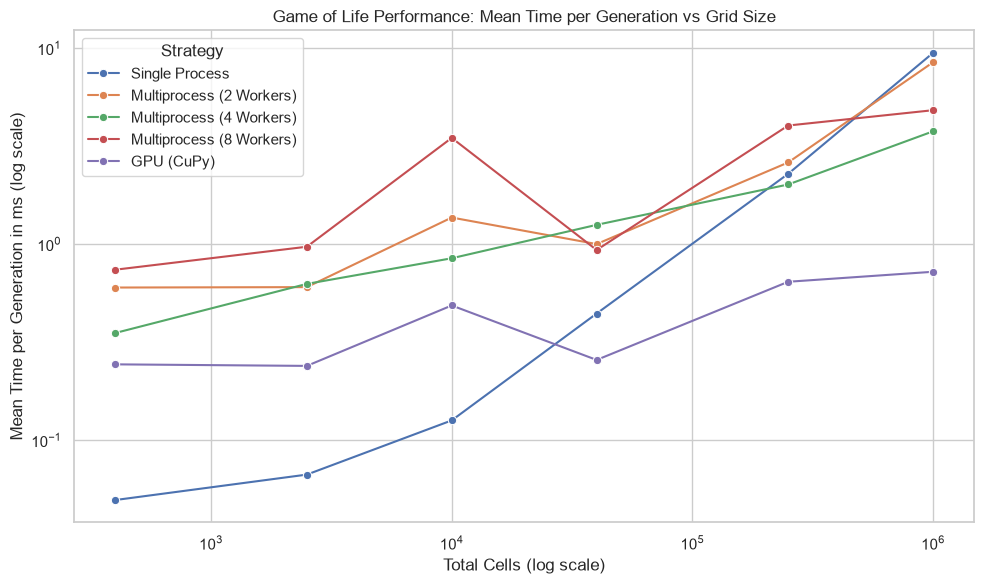

In [3]:
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Total Cells", y="Mean Time (ms)", hue="Strategy", marker="o")

plt.xscale("log")
plt.yscale("log")
plt.title("Game of Life Performance: Mean Time per Generation vs Grid Size")
plt.xlabel("Total Cells (log scale)")
plt.ylabel("Mean Time per Generation in ms (log scale)")
plt.legend(title="Strategy")
plt.tight_layout()
plt.show()

## Conclusion

Based on the generated plot, we can observe the crossover point where multiprocessing overhead is overcome by parallel speedup. This value should be updated in `config.yaml` / `config.py` as the `multiprocessing_threshold_cells` value, and noted in `context.md`.

### 3. CPU Core Affinity & Numba Ablation Study
This study explicitly compares configurations handling Game of Life generation computation and P/E-core synchronization.

**Permutations to test:**
1. Multiprocessing (SciPy) on **ALL Cores**
2. Multiprocessing (SciPy) on **P-Cores ONLY**
3. Numba on **ALL Cores**
4. Numba on **P-Cores ONLY**

Below is the experimental setup.

In [4]:
import time
import numpy as np
import pandas as pd
from pathlib import Path
import psutil

from libs.config import ComputeBackend, SimulationConfig
from libs.core.engine import SimulationEngine
from libs.parallel.topology import get_topology_info

def run_ablation_test(backend: ComputeBackend, all_cores: bool, steps=50):
    """Run an ablation test and return results."""
    config = SimulationConfig()
    config.backend = backend
    config.all_cores = all_cores

    # Topology extraction
    p_cores, e_cores = get_topology_info()
    proc = psutil.Process()

    # Apply affinity manually for testing
    if all_cores or not e_cores:
        proc.cpu_affinity(p_cores + e_cores)
    else:
        proc.cpu_affinity(p_cores)

    initial = np.random.choice([0, 1], size=(500, 500), p=[0.8, 0.2]).astype(np.uint8)
    engine = SimulationEngine(config=config, initial=initial)

    start_time = time.time()
    for _ in range(steps):
        engine.step()
    elapsed = time.time() - start_time

    affinity_desc = "ALL Cores" if all_cores else "P-Cores ONLY"
    backend_desc = "Numba" if backend == ComputeBackend.NUMBA else "SciPy"
    steps_per_sec = steps / elapsed
    print(
        f"{backend_desc} on {affinity_desc} -> {steps} steps "
        f"in {elapsed:.3f}s ({steps_per_sec:.1f} steps/s)"
    )
    
    return {
        "Backend": backend_desc,
        "Affinity": affinity_desc,
        "Steps/s": steps_per_sec
    }

print("--- ABLATION STUDY RESULTS ---")
results_ablation = []
results_ablation.append(run_ablation_test(ComputeBackend.CPU, all_cores=True))
results_ablation.append(run_ablation_test(ComputeBackend.CPU, all_cores=False))
results_ablation.append(run_ablation_test(ComputeBackend.NUMBA, all_cores=True))
results_ablation.append(run_ablation_test(ComputeBackend.NUMBA, all_cores=False))

df_ablation = pd.DataFrame(results_ablation)
display(df_ablation)


--- ABLATION STUDY RESULTS ---
SciPy on ALL Cores -> 50 steps in 2.053s (24.4 steps/s)
SciPy on P-Cores ONLY -> 50 steps in 2.034s (24.6 steps/s)
Numba on ALL Cores -> 50 steps in 2.383s (21.0 steps/s)
Numba on P-Cores ONLY -> 50 steps in 1.521s (32.9 steps/s)


,Backend,Affinity,Steps/s
0,SciPy,ALL Cores,24.359727
1,SciPy,P-Cores ONLY,24.585967
2,Numba,ALL Cores,20.980260
3,Numba,P-Cores ONLY,32.864529


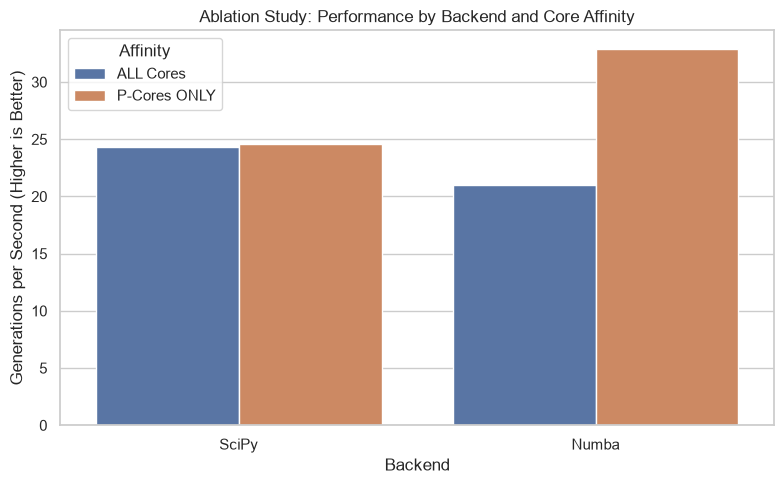

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.barplot(data=df_ablation, x="Backend", y="Steps/s", hue="Affinity")
plt.title("Ablation Study: Performance by Backend and Core Affinity")
plt.ylabel("Generations per Second (Higher is Better)")
plt.tight_layout()
plt.show()


### Interpretation of Results

1. **CPU Topology (P-Cores vs All Cores):** 
   On hybrid architectures (like Intel 12th/13th Gen), using **ALL Cores** often results in significantly lower performance than using **P-Cores ONLY**. This is because the OS scheduler assigns work to slower E-Cores, causing the fast P-Cores to idle while waiting for the E-Cores to finish their chunk of the grid (the weakest link problem in synchronous multiprocessing). Restricting the process affinity to P-Cores eliminates this bottleneck and maximizes throughput. On non-hybrid architectures, the two affinity settings will perform identically.

2. **SciPy vs Numba JIT:**
   The `SciPy` backend relies on `scipy.ndimage.convolve` coupled with `multiprocessing.shared_memory`. This is highly optimized but incurs overhead. The `Numba` backend uses LLVM JIT compilation with `@njit(parallel=True)` to natively multithread the nested loops in C-like speeds without the overhead of multiple processes. Depending on the exact CPU and grid size, Numba often achieves higher `Steps/s`, making it a powerful alternative engine.
